In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('/content/store_sales.csv')
df.head()

,CustomerID,Age,Gender,Category,ItemPurchased,Amount,Season,PaymentMethod,ItemRating,DiscountApplied(%),PreviousPurchases
0,1,58,Female,Accessories,Handbag,115.50,Autumn,Card,3.5,18,4
1,2,40,Male,Mens Clothing,Shirt,103.43,Spring,Card,4.1,13,4
2,3,66,Female,Sports,Football,35.45,Spring,Card,3.3,11,3
3,4,39,Female,Accessories,Handbag,153.31,Spring,Card,4.4,13,4
4,5,23,Female,Home,Curtains,151.43,Winter,Card,4.1,20,10


In [4]:
df.columns

Index(['CustomerID', 'Age', 'Gender', 'Category', 'ItemPurchased', 'Amount',
       'Season', 'PaymentMethod', 'ItemRating', 'DiscountApplied(%)',
       'PreviousPurchases'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CustomerID          5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Gender              5000 non-null   object 
 3   Category            5000 non-null   object 
 4   ItemPurchased       5000 non-null   object 
 5   Amount              5000 non-null   float64
 6   Season              5000 non-null   object 
 7   PaymentMethod       5000 non-null   object 
 8   ItemRating          5000 non-null   float64
 9   DiscountApplied(%)  5000 non-null   int64  
 10  PreviousPurchases   5000 non-null   int64  
dtypes: float64(2), int64(4), object(5)
memory usage: 429.8+ KB


In [6]:
df.shape

(5000, 11)

In [8]:
df.describe()

,CustomerID,Age,Amount,ItemRating,DiscountApplied(%),PreviousPurchases
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2500.500000,45.224800,285.090522,3.784160,14.983600,5.008800
std,1443.520003,14.564995,551.454382,0.681796,5.988063,2.194285
min,1.000000,20.000000,5.080000,1.100000,0.000000,0.000000
25%,1250.750000,33.000000,70.547500,3.300000,11.000000,3.000000
50%,2500.500000,45.000000,122.485000,3.800000,15.000000,5.000000
75%,3750.250000,58.000000,184.535000,4.300000,19.000000,6.000000
max,5000.000000,70.000000,2997.940000,5.000000,36.000000,13.000000


In [9]:
df.isnull().sum()

,0
CustomerID,0
Age,0
Gender,0
Category,0
ItemPurchased,0
Amount,0
Season,0
PaymentMethod,0
ItemRating,0
DiscountApplied(%),0


In [10]:
high_discount = df[df['DiscountApplied(%)'] >= df['DiscountApplied(%)'].median()]['Amount']

low_discount = df[df['DiscountApplied(%)'] < df['DiscountApplied(%)'].median()]['Amount']

In [11]:
# Null Hypothesis (H₀): High-discount orders and low-discount orders have the same average sales amount.
# Alternative Hypothesis (H₁): High-discount orders have a different average sales amount.

In [12]:
# Independent t-Test
from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(high_discount, low_discount)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -0.37630386700386975
P-value: 0.706706977433816


In [13]:
alpha = 0.05

if p_value < alpha:
    print("Discounts significantly affect sales amount.")
else:
    print("No significant evidence that discounts affect sales amount.")

No significant evidence that discounts affect sales amount.


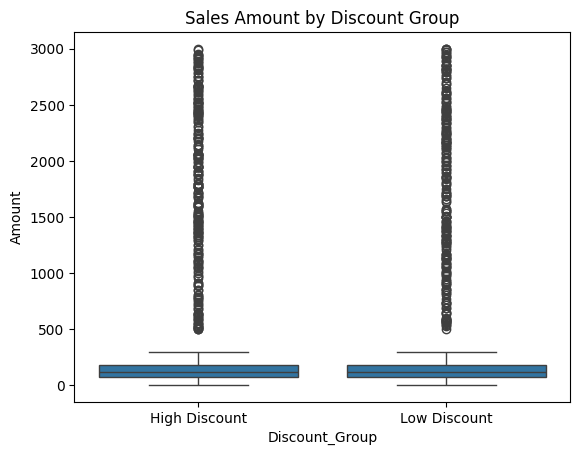

In [14]:
# visulaization

df['Discount_Group'] = df['DiscountApplied(%)'].apply(
    lambda x: 'High Discount' if x >= df['DiscountApplied(%)'].median()
    else 'Low Discount'
)

sns.boxplot(x='Discount_Group', y='Amount', data=df)

plt.title('Sales Amount by Discount Group')
plt.show()